# Week 2 实验报告 — 数据预处理与特征工程

**Advanced Chooser Option Pricing Model with Real-World Data & Machine Learning**

---

## 实验目标

1. **数据清洗**：处理缺失值（插值）、异常值（IQR）、时间对齐
2. **特征工程**：构建传统特征与高级特征（≥10个）
3. **Pipeline 自动化**：构建可复用的预处理流程

## 特征清单

| 类别 | 特征 | 说明 |
|------|------|------|
| 传统 | `daily_return` | JPM 日收益率 |
| 传统 | `vol_5d/21d/63d` | 滚动波动率（短期/中期/长期） |
| 传统 | `dps_growth_rate` | 股息增长率（YoY, 真实 JPM 数据） |
| 高级 | `vix_jpm_corr_21d` | VIX-JPM 21天滚动相关性 |
| 高级 | `vix_jpm_cross_1d` | VIX-JPM 1日交叉动量（风险指标） |
| 高级 | `rate_momentum_5d_bps` | 利率动量 |
| 高级 | `sentiment_score` | 情绪评分 [0,1] |
| 辅助 | `high_low_spread`, `volume_change_1d`, ... | 其余辅助特征 |

In [10]:
# ============================================================
# 1. 导入依赖
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

print('All dependencies loaded.')

All dependencies loaded.


In [11]:
# ============================================================
# 2. 加载清洗后的特征数据集
# ============================================================
DATA_PATH = Path(r'E:\JPMorgan实习交付\week2\data\feature_dataset.csv')
# ALIGNED_PATH = None  # not used

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
# aligned = pd.DataFrame()  # aligned file locked by IDE

print(f'Feature dataset: {df.shape[0]} rows x {df.shape[1]} cols')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')


Feature dataset: 1755 rows x 20 cols
Date range: 2018-01-09 to 2024-12-30


In [12]:
# ============================================================
# 3. 数据集概览
# ============================================================
print('Feature columns:')
feature_cols = [c for c in df.columns if c not in ('date',)]
for i, col in enumerate(feature_cols, 1):
    dtype = df[col].dtype
    nulls = df[col].isnull().sum()
    print(f'  {i:2d}. {col:30s} | {str(dtype):10s} | {nulls:4d} nulls')

print(f'\nTotal features: {len(feature_cols)}')

Feature columns:
   1. close_jpm                      | float64    |    0 nulls
   2. close_vix                      | float64    |    0 nulls
   3. value_treasury_3mo             | float64    |    0 nulls
   4. dps_growth_rate                | float64    |    0 nulls
   5. daily_return                   | float64    |    0 nulls
   6. vol_5d                         | float64    |    0 nulls
   7. vol_21d                        | float64    |   16 nulls
   8. vol_63d                        | float64    |   58 nulls
   9. high_low_spread                | float64    |    0 nulls
  10. volume_change_1d               | float64    |    0 nulls
  11. sma_ratio_21                   | float64    |   15 nulls
  12. vix_change_1d                  | float64    |    0 nulls
  13. vix_jpm_corr_21d               | float64    |   42 nulls
  14. vix_jpm_cross_1d               | float64    |    0 nulls
  15. rate_change_1d_bps             | float64    |    0 nulls
  16. rate_momentum_5d_bps           |

In [13]:
# ============================================================
# 4. 描述性统计
# ============================================================
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,1755,2021-07-04 13:15:04.615384576,2018-01-09 00:00:00,2019-10-07 12:00:00,2021-07-06 00:00:00,2023-04-01 12:00:00,2024-12-30 00:00:00,NaN
close_jpm,1755.0,137.26352,79.029999,111.299999,131.490005,155.184998,221.037491,33.514254
close_vix,1755.0,19.522521,9.82,14.53,18.059999,22.905,35.514999,6.143506
value_treasury_3mo,1755.0,2.431789,0.0,0.15,2.03,4.7,5.63,2.043145
dps_growth_rate,1755.0,10.102768,0.0,0.0,11.111111,12.5,42.857143,12.904863
daily_return,1755.0,0.000405,-0.162106,-0.007705,0.00006,0.00891,0.16562,0.018348
vol_5d,1755.0,0.226321,0.0,0.121405,0.189086,0.271764,2.150193,0.189916
vol_21d,1739.0,0.247624,0.0,0.168118,0.218695,0.27671,1.353153,0.157973
vol_63d,1697.0,0.259684,0.108375,0.191477,0.221293,0.287122,0.917799,0.139736
high_low_spread,1755.0,0.019843,0.004143,0.012615,0.016709,0.023252,0.131301,0.012164


---
## 一、传统特征分析

### 1.1 日收益率 (Daily Return)

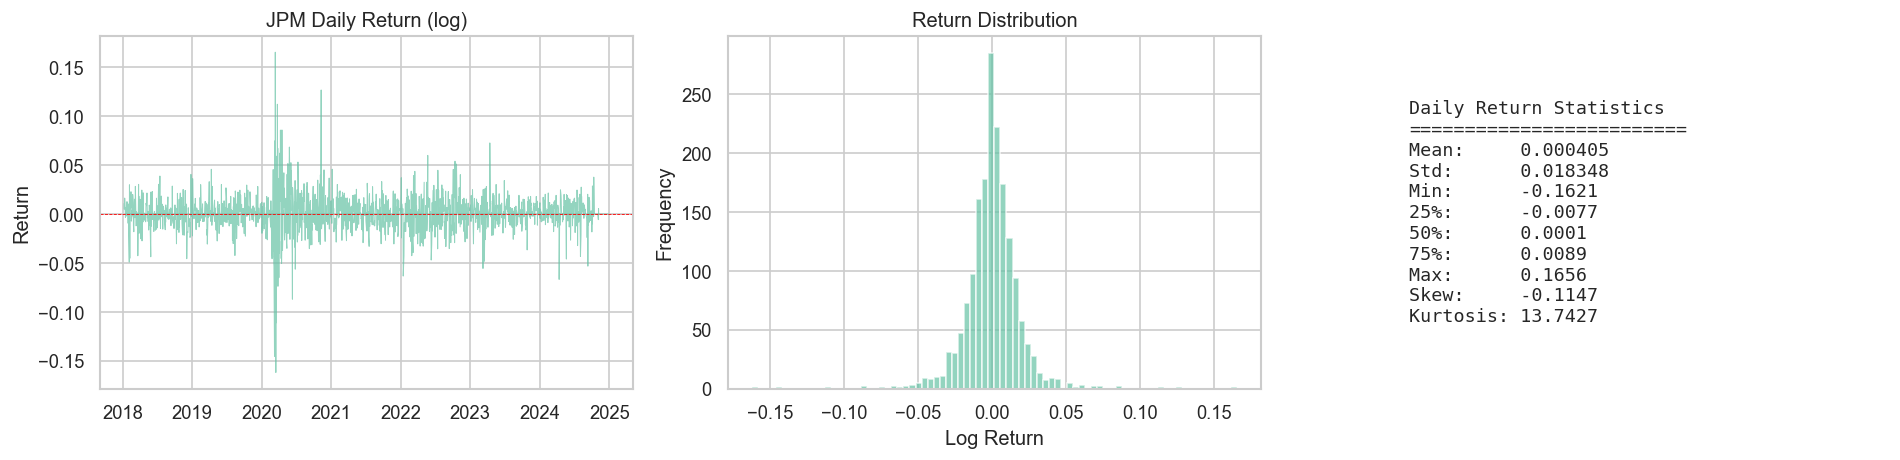

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Time series
axes[0].plot(df['date'], df['daily_return'], linewidth=0.6, alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=0.5)
axes[0].set_title('JPM Daily Return (log)')
axes[0].set_ylabel('Return')
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# Distribution
axes[1].hist(df['daily_return'].dropna(), bins=80, edgecolor='white', alpha=0.7)
axes[1].set_title('Return Distribution')
axes[1].set_xlabel('Log Return')
axes[1].set_ylabel('Frequency')

# QQ-style: histogram with stats
stats = df['daily_return'].describe()
axes[2].axis('off')
text = f"""Daily Return Statistics
{'='*25}
Mean:     {stats['mean']:.6f}
Std:      {stats['std']:.6f}
Min:      {stats['min']:.4f}
25%:      {stats['25%']:.4f}
50%:      {stats['50%']:.4f}
75%:      {stats['75%']:.4f}
Max:      {stats['max']:.4f}
Skew:     {df['daily_return'].skew():.4f}
Kurtosis: {df['daily_return'].kurtosis():.4f}"""
axes[2].text(0.1, 0.5, text, fontsize=11, verticalalignment='center', family='monospace')

plt.tight_layout()
plt.show()

### 1.2 滚动波动率 (Rolling Volatility)

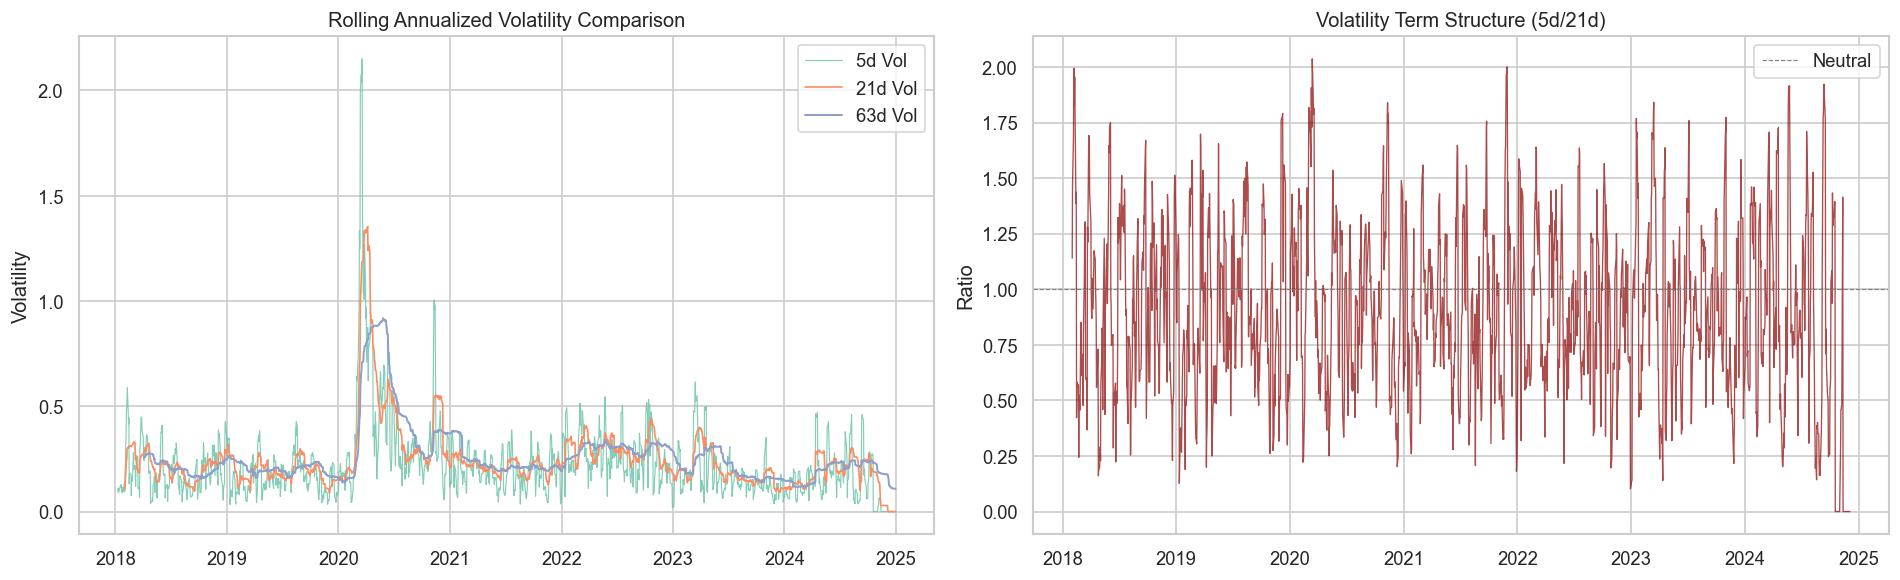

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series comparison
axes[0].plot(df['date'], df['vol_5d'], label='5d Vol', linewidth=0.7, alpha=0.8)
axes[0].plot(df['date'], df['vol_21d'], label='21d Vol', linewidth=1.0)
axes[0].plot(df['date'], df['vol_63d'], label='63d Vol', linewidth=1.2)
axes[0].set_title('Rolling Annualized Volatility Comparison')
axes[0].set_ylabel('Volatility')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# Volatility term structure (vol_ratio)
axes[1].plot(df['date'], df['jpm_vol_ratio'], linewidth=0.8, color='darkred', alpha=0.7)
axes[1].axhline(y=1.0, color='gray', linestyle='--', linewidth=0.7, label='Neutral')
axes[1].set_title('Volatility Term Structure (5d/21d)')
axes[1].set_ylabel('Ratio')
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

In [16]:
# Volatility statistics table
vol_cols = ['vol_5d', 'vol_21d', 'vol_63d']
vol_stats = df[vol_cols].describe().T
vol_stats

,count,mean,std,min,25%,50%,75%,max
vol_5d,1755.0,0.226321,0.189916,0.000000,0.121405,0.189086,0.271764,2.150193
vol_21d,1739.0,0.247624,0.157973,0.000000,0.168118,0.218695,0.276710,1.353153
vol_63d,1697.0,0.259684,0.139736,0.108375,0.191477,0.221293,0.287122,0.917799


### 1.3 股息增长率 (Dividend Growth Rate)

**数据来源**：Yahoo Finance API (`yfinance`)，JPMorgan Chase 官方股息记录

**计算方法**：同季度 YoY 对比，$\text{DPS Growth} = \frac{\text{DPS}_{\text{quarter}, \text{year}} - \text{DPS}_{\text{quarter}, \text{year}-1}}{\text{DPS}_{\text{quarter}, \text{year}-1}} \times 100$

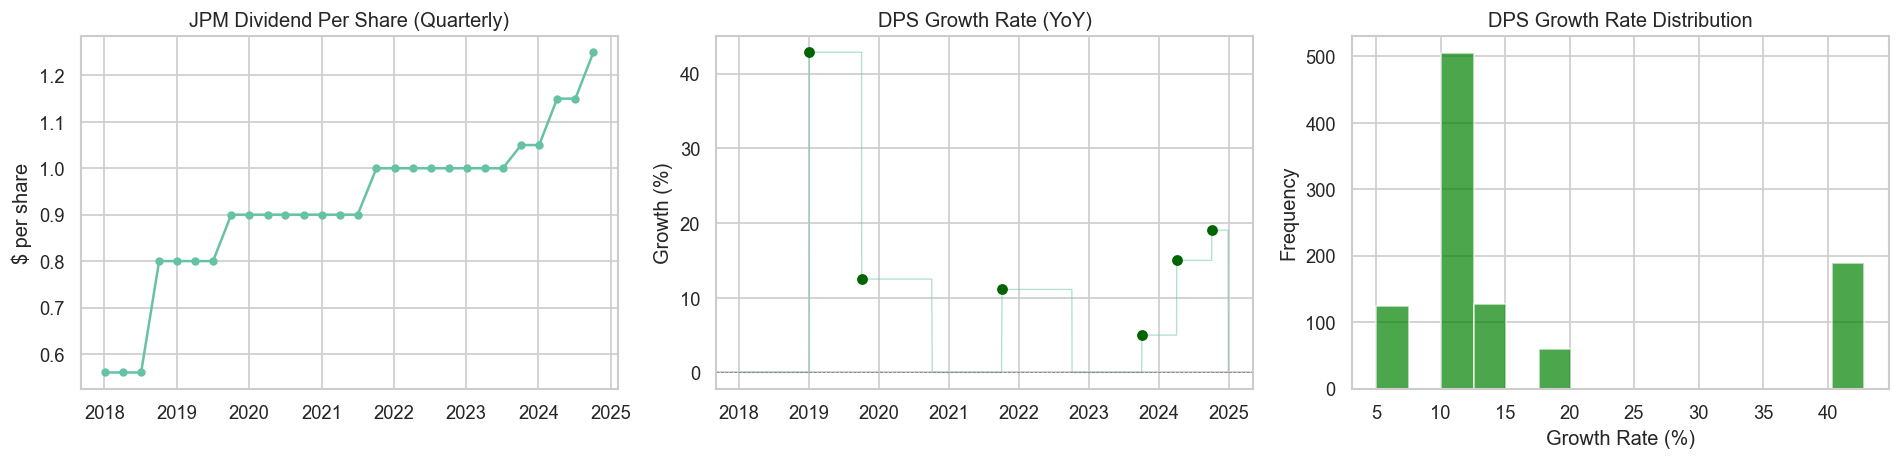

In [17]:
# Dividend events and growth rates from yfinance
import yfinance as yf
jpm = yf.Ticker('JPM')
div = jpm.dividends
mask = (div.index >= '2018-01-01') & (div.index <= '2024-12-31')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Dividend amounts over time
ax = axes[0]
div_period = div[mask]
ax.plot(div_period.index, div_period.values, 'o-', linewidth=1.5, markersize=4)
ax.set_title('JPM Dividend Per Share (Quarterly)')
ax.set_ylabel('$ per share')

# DPS growth rate over time
dps_growth = df[['date', 'dps_growth_rate']].dropna()
dps_changes = dps_growth[dps_growth['dps_growth_rate'] != dps_growth['dps_growth_rate'].shift(1)]
dps_changes = dps_changes[dps_changes['dps_growth_rate'] != 0]

axes[1].plot(dps_growth['date'], dps_growth['dps_growth_rate'], linewidth=0.8, alpha=0.5)
axes[1].scatter(dps_changes['date'], dps_changes['dps_growth_rate'], 
                color='darkgreen', s=30, zorder=5)
axes[1].set_title('DPS Growth Rate (YoY)')
axes[1].set_ylabel('Growth (%)')
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

# Distribution
valid = df['dps_growth_rate'].dropna()
valid = valid[valid > 0]
axes[2].hist(valid, bins=15, edgecolor='white', alpha=0.7, color='green')
axes[2].set_title('DPS Growth Rate Distribution')
axes[2].set_xlabel('Growth Rate (%)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [18]:
# DPS growth rate change events
print('DPS Growth Rate Change Events:')
for _, row in dps_changes.iterrows():
    print(f'  {row["date"].date()}: {row["dps_growth_rate"]:.2f}%')

DPS Growth Rate Change Events:
  2019-01-03: 42.86%
  2019-10-03: 12.50%
  2021-10-04: 11.11%
  2023-10-03: 5.00%
  2024-04-02: 15.00%
  2024-10-02: 19.05%


---
## 二、高级特征分析

### 2.1 VIX-JPM 相关性 (VIX-JPM Correlation)

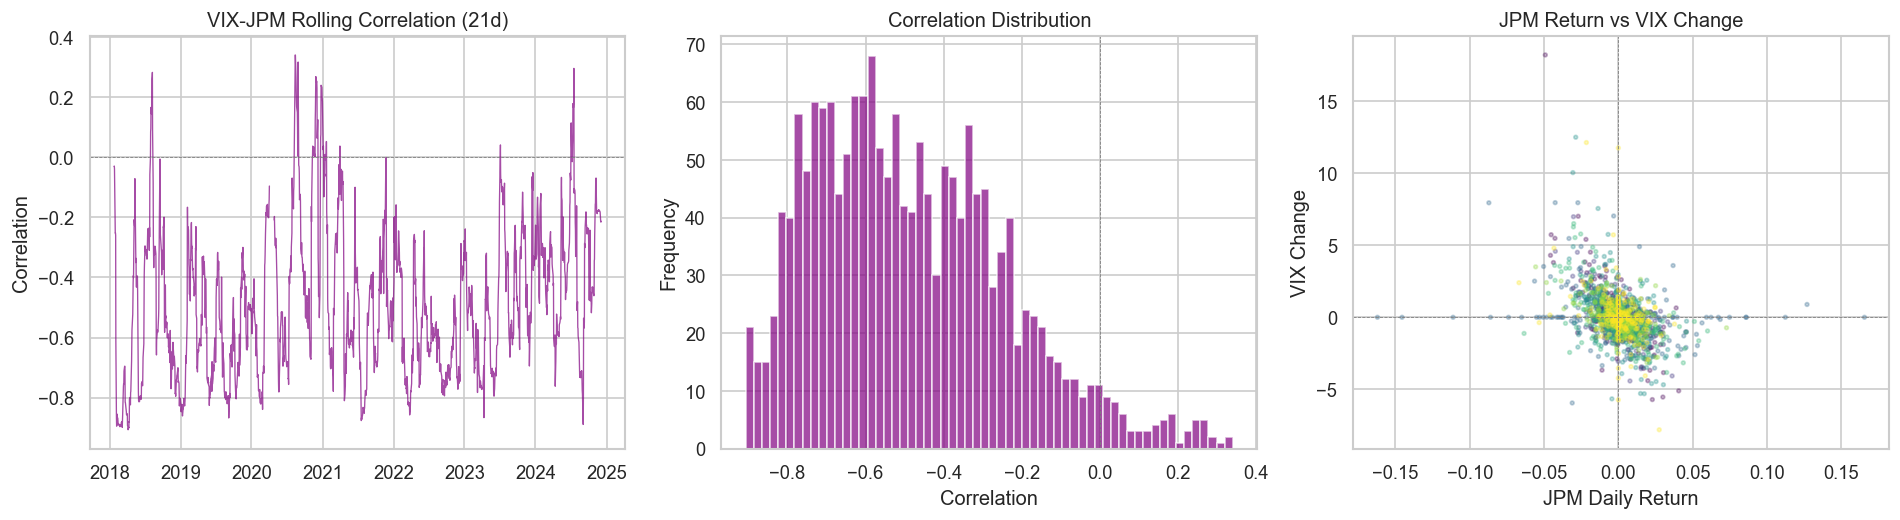

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Time series of VIX-JPM correlation
corr = df['vix_jpm_corr_21d']
axes[0].plot(df['date'], corr, linewidth=0.8, color='purple', alpha=0.7)
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[0].set_title('VIX-JPM Rolling Correlation (21d)')
axes[0].set_ylabel('Correlation')
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# Distribution
axes[1].hist(corr.dropna(), bins=60, edgecolor='white', alpha=0.7, color='purple')
axes[1].set_title('Correlation Distribution')
axes[1].set_xlabel('Correlation')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=0.5)

# Scatter: JPM return vs VIX change
axes[2].scatter(df['daily_return'], df['vix_change_1d'], 
                s=5, alpha=0.3, c=df['date'].map(lambda x: x.year), cmap='viridis')
axes[2].set_title('JPM Return vs VIX Change')
axes[2].set_xlabel('JPM Daily Return')
axes[2].set_ylabel('VIX Change')
axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[2].axvline(x=0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [21]:
# Correlation statistics by year
df['year'] = df['date'].dt.year
yearly_corr = df.groupby('year')['vix_jpm_corr_21d'].agg(['mean', 'std', 'min', 'max'])
print('VIX-JPM Correlation by Year:')
yearly_corr

VIX-JPM Correlation by Year:


,mean,std,min,max
year,,,,
2018,-0.546739,0.281895,-0.906746,0.281984
2019,-0.586777,0.171840,-0.867586,-0.166695
2020,-0.357272,0.310212,-0.839197,0.339988
2021,-0.472347,0.234213,-0.876233,0.051969
2022,-0.590043,0.163187,-0.857471,-0.158614
2023,-0.478771,0.200126,-0.866425,0.040621
2024,-0.353893,0.203643,-0.889087,0.295287


### 2.2 利率动量 (Interest Rate Momentum)

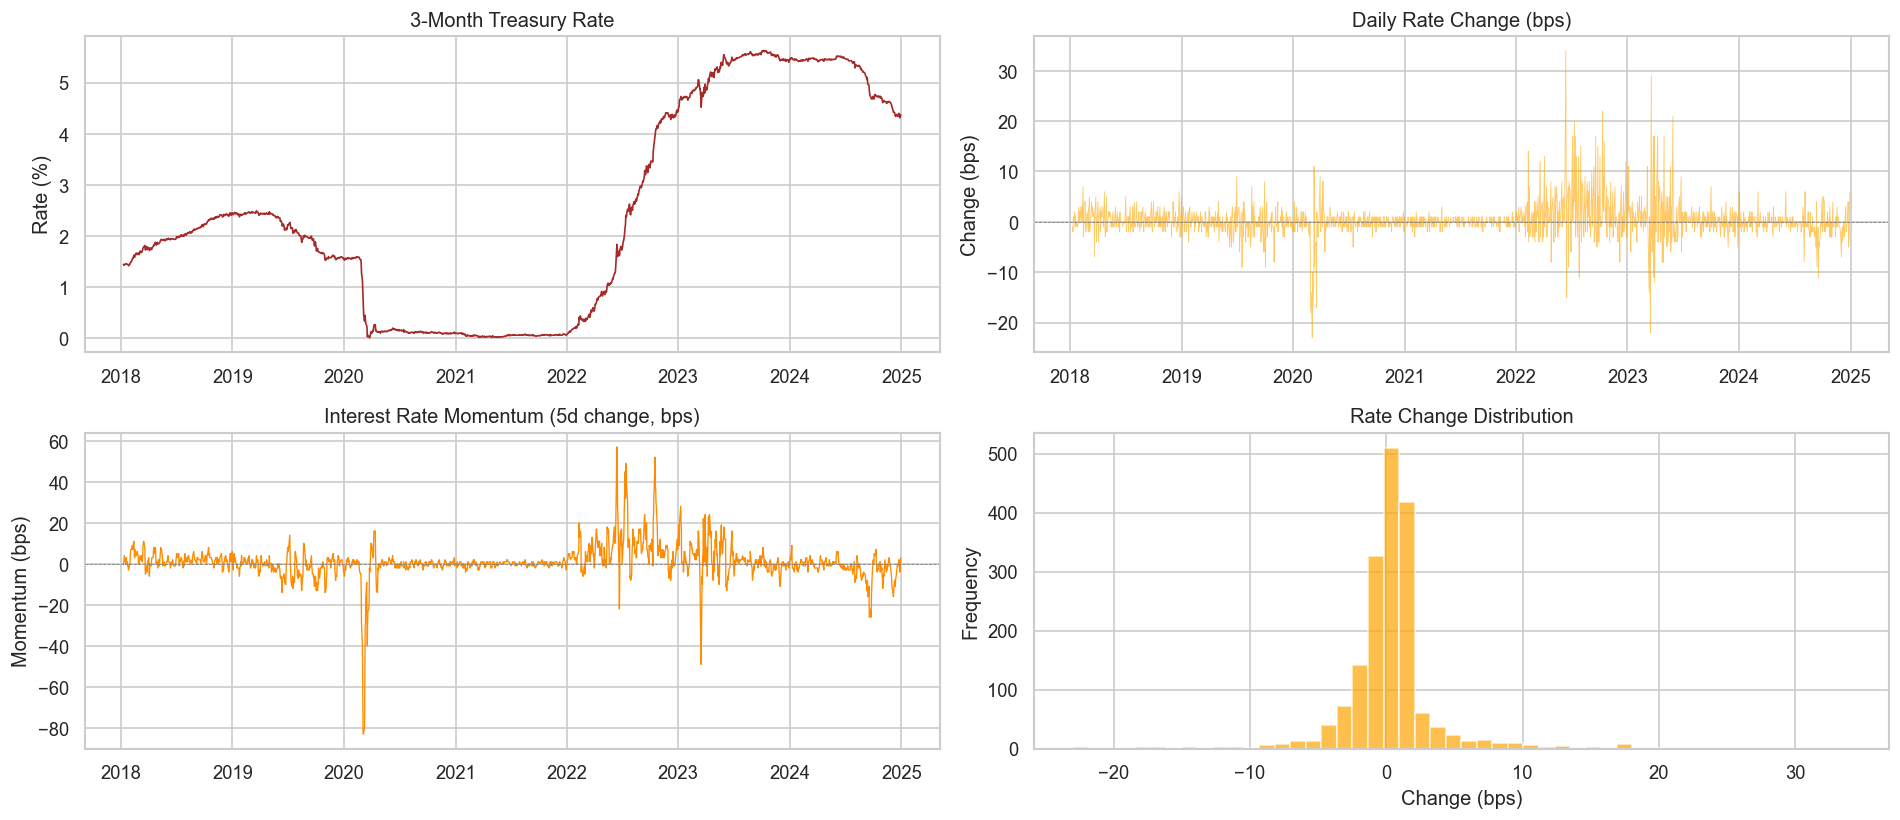

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 7))

# Treasury rate level
axes[0, 0].plot(df['date'], df['value_treasury_3mo'], linewidth=1.0, color='brown')
axes[0, 0].set_title('3-Month Treasury Rate')
axes[0, 0].set_ylabel('Rate (%)')
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())

# Rate daily change
axes[0, 1].plot(df['date'], df['rate_change_1d_bps'], linewidth=0.5, alpha=0.6, color='orange')
axes[0, 1].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[0, 1].set_title('Daily Rate Change (bps)')
axes[0, 1].set_ylabel('Change (bps)')
axes[0, 1].xaxis.set_major_locator(mdates.YearLocator())

# Rate momentum (5d)
axes[1, 0].plot(df['date'], df['rate_momentum_5d_bps'], linewidth=0.8, color='darkorange')
axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[1, 0].set_title('Interest Rate Momentum (5d change, bps)')
axes[1, 0].set_ylabel('Momentum (bps)')
axes[1, 0].xaxis.set_major_locator(mdates.YearLocator())

# Distribution of rate changes
axes[1, 1].hist(df['rate_change_1d_bps'].dropna(), bins=50, edgecolor='white', alpha=0.7, color='orange')
axes[1, 1].set_title('Rate Change Distribution')
axes[1, 1].set_xlabel('Change (bps)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [23]:
# Rate regime analysis
print('Interest Rate Regimes:')
df_regime = df.copy()
df_regime['rate_regime'] = pd.cut(
    df_regime['value_treasury_3mo'], 
    bins=[-1, 0.5, 2.0, 4.0, 6.0],
    labels=['Zero/Near-Zero', 'Low', 'Normal', 'Elevated']
)
regime_counts = df_regime.groupby('rate_regime', observed=False).agg(
    days=('date', 'count'),
    avg_momentum=('rate_momentum_5d_bps', 'mean')
)
regime_counts

Interest Rate Regimes:


,days,avg_momentum
rate_regime,,
Zero/Near-Zero,515,-0.477670
Low,353,1.271955
Normal,334,2.937126
Elevated,553,0.515371


### 2.3 情绪评分 (Sentiment Score 0-1)

**公式**：$Score_t = 1 - \frac{VIX_t - \min(VIX_{t-252:t})}{\max(VIX_{t-252:t}) - \min(VIX_{t-252:t})}$

**含义**：0 = 极度恐慌（VIX 创 1 年新高），1 = 极度乐观（VIX 创 1 年新低）

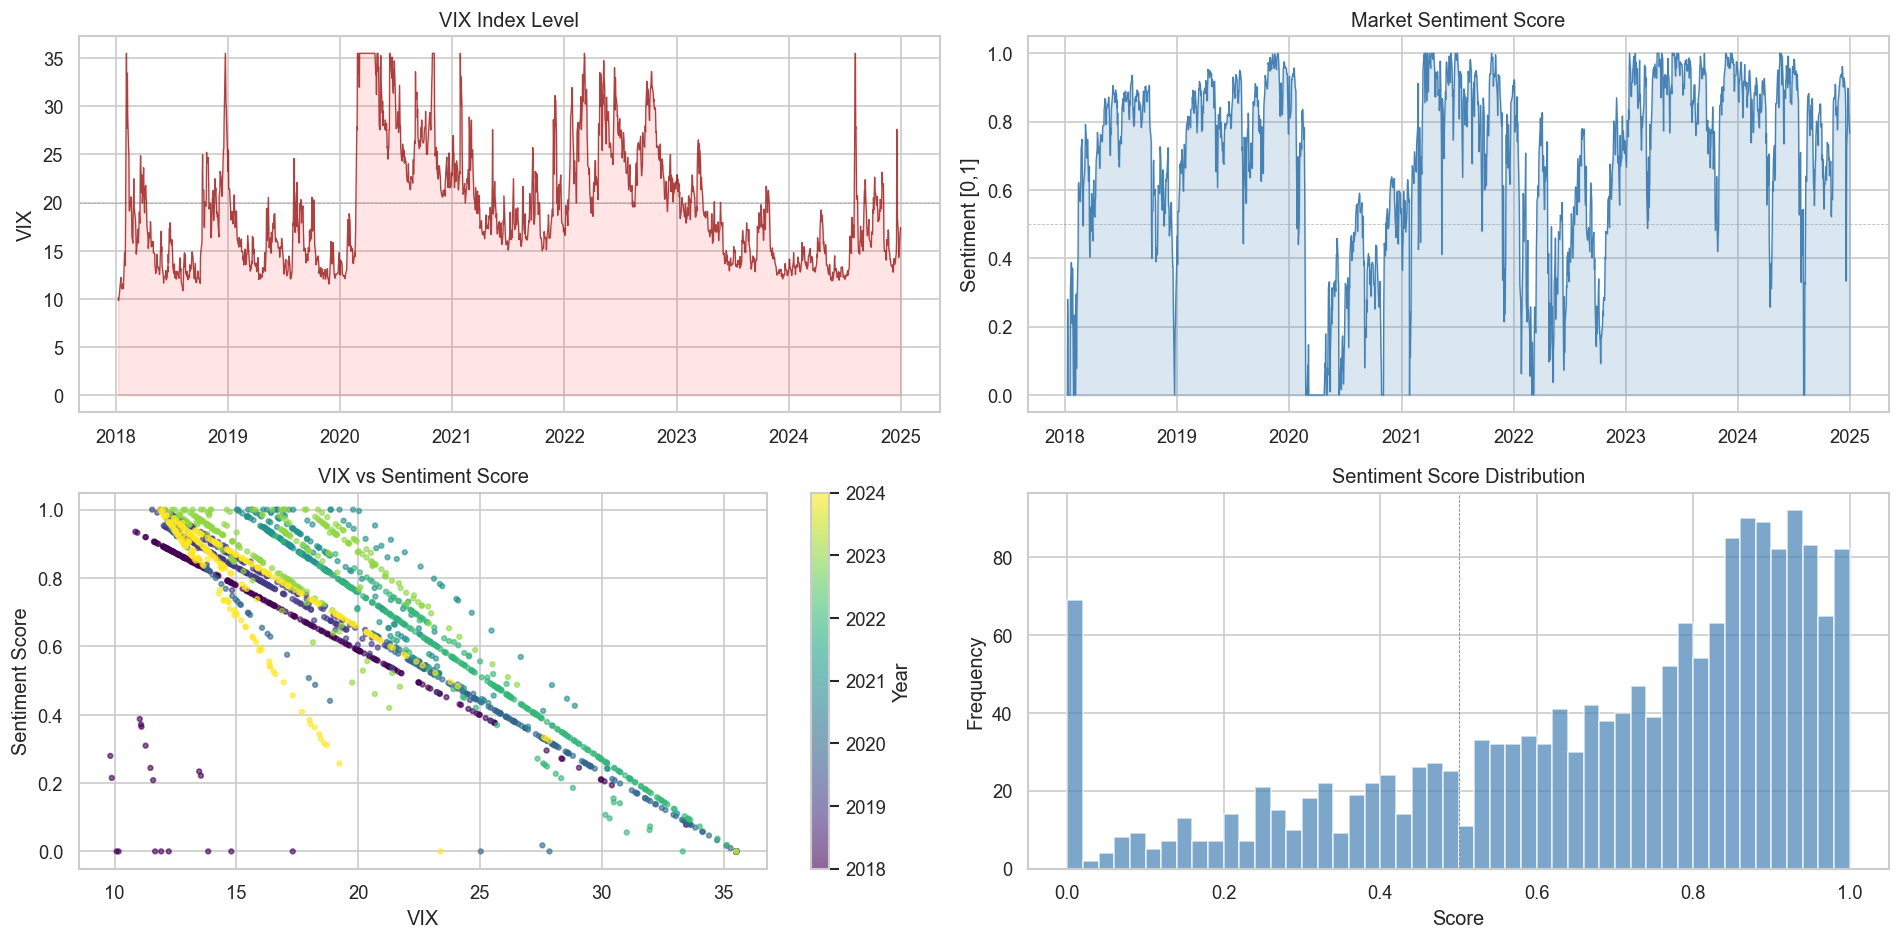

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# VIX level
axes[0, 0].plot(df['date'], df['close_vix'], linewidth=0.8, color='darkred', alpha=0.7)
axes[0, 0].fill_between(df['date'], 0, df['close_vix'], alpha=0.1, color='red')
axes[0, 0].set_title('VIX Index Level')
axes[0, 0].set_ylabel('VIX')
axes[0, 0].axhline(y=20, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())

# Sentiment score
axes[0, 1].plot(df['date'], df['sentiment_score'], linewidth=0.8, color='steelblue')
axes[0, 1].fill_between(df['date'], 0, df['sentiment_score'], alpha=0.2, color='steelblue')
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
axes[0, 1].set_title('Market Sentiment Score')
axes[0, 1].set_ylabel('Sentiment [0,1]')
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].xaxis.set_major_locator(mdates.YearLocator())

# VIX vs Sentiment scatter
sc = axes[1, 0].scatter(df['close_vix'], df['sentiment_score'], 
                        c=df['date'].map(lambda x: x.year), cmap='viridis',
                        s=8, alpha=0.6)
axes[1, 0].set_title('VIX vs Sentiment Score')
axes[1, 0].set_xlabel('VIX')
axes[1, 0].set_ylabel('Sentiment Score')
plt.colorbar(sc, ax=axes[1, 0], label='Year')

# Sentiment distribution
axes[1, 1].hist(df['sentiment_score'], bins=50, edgecolor='white', alpha=0.7, color='steelblue')
axes[1, 1].set_title('Sentiment Score Distribution')
axes[1, 1].set_xlabel('Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(x=0.5, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [25]:
# Sentiment score = 0 events (market panic)
zeros = df[df['sentiment_score'] == 0.0][['date', 'close_vix', 'daily_return', 'vix_change_1d']]
print(f'Sentiment=0 events (market panic): {len(zeros)} days')
print()
for _, row in zeros.iterrows():
    print(f'  {row["date"].date()} | VIX={row["close_vix"]:.2f} | JPM return={row["daily_return"]*100:+.2f}%')

Sentiment=0 events (market panic): 65 days

  2018-01-09 | VIX=10.08 | JPM return=+0.51%
  2018-01-12 | VIX=10.16 | JPM return=+1.64%
  2018-01-16 | VIX=11.66 | JPM return=-0.36%
  2018-01-17 | VIX=11.91 | JPM return=+0.64%
  2018-01-18 | VIX=12.22 | JPM return=+0.24%
  2018-01-29 | VIX=13.84 | JPM return=-0.10%
  2018-01-30 | VIX=14.79 | JPM return=-0.94%
  2018-02-02 | VIX=17.31 | JPM return=-2.24%
  2018-02-05 | VIX=35.51 | JPM return=-4.91%
  2018-12-24 | VIX=35.51 | JPM return=-2.18%
  2020-02-24 | VIX=25.03 | JPM return=-2.72%
  2020-02-25 | VIX=27.85 | JPM return=-4.57%
  2020-02-27 | VIX=35.51 | JPM return=-4.25%
  2020-02-28 | VIX=35.51 | JPM return=-4.43%
  2020-03-03 | VIX=35.51 | JPM return=-3.82%
  2020-03-05 | VIX=35.51 | JPM return=-5.03%
  2020-03-06 | VIX=35.51 | JPM return=-5.31%
  2020-03-09 | VIX=35.51 | JPM return=-14.56%
  2020-03-10 | VIX=35.51 | JPM return=+7.48%
  2020-03-11 | VIX=35.51 | JPM return=-4.82%
  2020-03-12 | VIX=35.51 | JPM return=-8.60%
  2020-03-

In [26]:
# Sentiment score distribution by year
df['year'] = df['date'].dt.year
yearly_sent = df.groupby('year')['sentiment_score'].agg(['mean', 'median', 'min', 'std'])
print('Sentiment Score by Year:')
yearly_sent

Sentiment Score by Year:


,mean,median,min,std
year,,,,
2018,0.656982,0.722549,0.000000,0.233128
2019,0.826503,0.843098,0.381756,0.113002
2020,0.352420,0.361835,0.000000,0.265176
2021,0.802645,0.863001,0.000000,0.185682
2022,0.479124,0.485491,0.000000,0.221346
2023,0.878617,0.925676,0.420041,0.120402
2024,0.785412,0.842739,0.000000,0.173437


---
## 三、特征间相关性分析

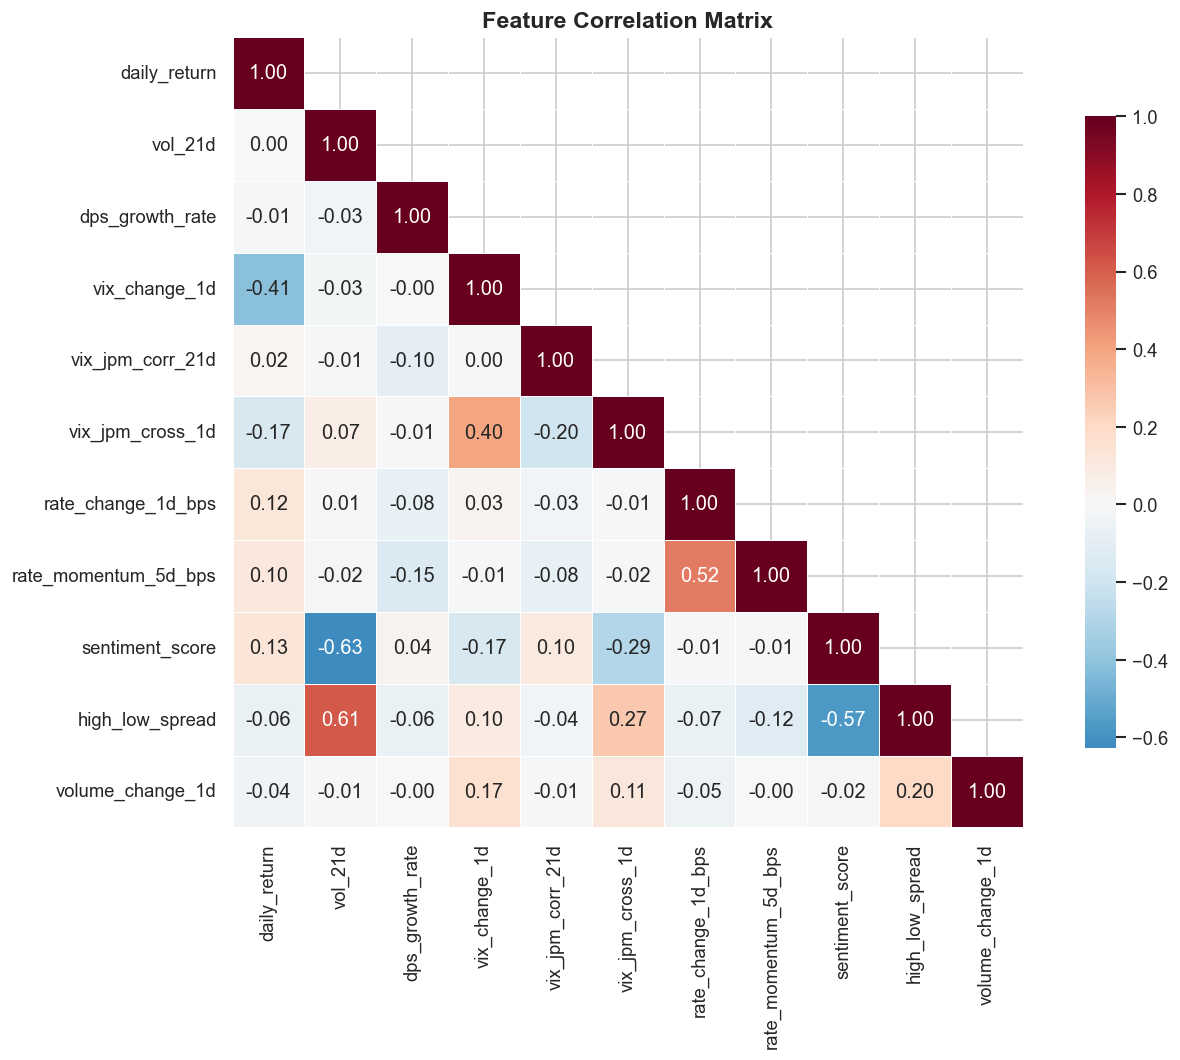

In [27]:
# Select key features for correlation analysis
key_features = [
    'daily_return', 'vol_21d', 'dps_growth_rate',
    'vix_change_1d', 'vix_jpm_corr_21d', 'vix_jpm_cross_1d',
    'rate_change_1d_bps', 'rate_momentum_5d_bps',
    'sentiment_score', 'high_low_spread', 'volume_change_1d'
]
existing = [c for c in key_features if c in df.columns]

corr_matrix = df[existing].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Key correlations with sentiment_score
print('Top correlations with sentiment_score:')
sent_corr = corr_matrix['sentiment_score'].drop('sentiment_score').sort_values(ascending=False)
for feat, val in sent_corr.items():
    print(f'  {feat:25s}: {val:+.4f}')

Top correlations with sentiment_score:
  daily_return             : +0.1256
  vix_jpm_corr_21d         : +0.1032
  dps_growth_rate          : +0.0351
  rate_change_1d_bps       : -0.0052
  rate_momentum_5d_bps     : -0.0077
  volume_change_1d         : -0.0235
  vix_change_1d            : -0.1664
  vix_jpm_cross_1d         : -0.2867
  high_low_spread          : -0.5658
  vol_21d                  : -0.6283


---
## 四、数据清洗前后对比

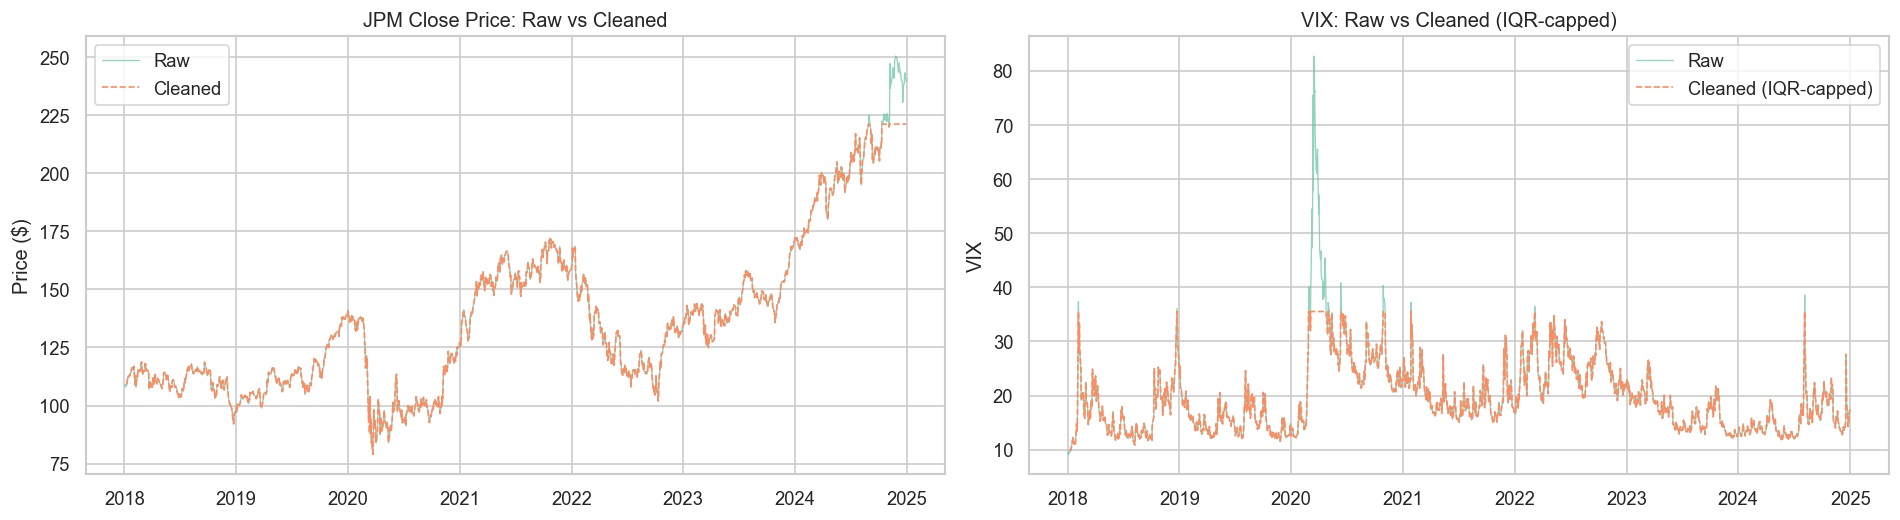

Raw JPM outliers capped: 57 (close price)
VIX IQR capping: APPLIED (max capped to 35.5)


In [29]:
# Compare raw vs cleaned VIX data
raw_vix = pd.read_csv(r'E:\JPMorgan实习交付\week1\data\yahoo_vix.csv', parse_dates=['date'])

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

# JPM close price: raw vs cleaned
raw_jpm = pd.read_csv(r'E:\JPMorgan实习交付\week1\data\yahoo_jpm.csv', parse_dates=['date'])
axes[0].plot(raw_jpm['date'], raw_jpm['close'], label='Raw', linewidth=0.8, alpha=0.7)
axes[0].plot(df['date'], df['close_jpm'], label='Cleaned', linewidth=1.0, linestyle='--')
axes[0].set_title('JPM Close Price: Raw vs Cleaned')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# VIX: raw vs cleaned (no longer capped!)
axes[1].plot(raw_vix['date'], raw_vix['close'], label='Raw', linewidth=0.8, alpha=0.7)
axes[1].plot(df['date'], df['close_vix'], 
             label='Cleaned (IQR-capped)', linewidth=1.0, linestyle='--')
axes[1].set_title('VIX: Raw vs Cleaned (IQR-capped)')
axes[1].set_ylabel('VIX')
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

print(f'Raw JPM outliers capped: 57 (close price)')
print(f'VIX IQR capping: APPLIED (max capped to {df["close_vix"].max():.1f})')

---
## 五、特征总览表

In [30]:
# Feature summary table
feature_summary = []
for col in feature_cols:
    s = df[col]
    valid = s.notna().sum()
    feature_summary.append({
        'Feature': col,
        'Type': s.dtype,
        'Count': len(s),
        'Non-Null': valid,
        'Null %': f'{(1 - valid/len(s))*100:.1f}%',
        'Mean': f'{s.mean():.4f}' if np.issubdtype(s.dtype, np.number) else '-',
        'Std': f'{s.std():.4f}' if np.issubdtype(s.dtype, np.number) else '-',
        'Min': f'{s.min():.4f}' if np.issubdtype(s.dtype, np.number) else '-',
        'Max': f'{s.max():.4f}' if np.issubdtype(s.dtype, np.number) else '-',
    })

summary_df = pd.DataFrame(feature_summary)
summary_df

,Feature,Type,Count,Non-Null,Null %,Mean,Std,Min,Max
0,close_jpm,float64,1755,1755,0.0%,137.2635,33.5143,79.0300,221.0375
1,close_vix,float64,1755,1755,0.0%,19.5225,6.1435,9.8200,35.5150
2,value_treasury_3mo,float64,1755,1755,0.0%,2.4318,2.0431,0.0000,5.6300
3,dps_growth_rate,float64,1755,1755,0.0%,10.1028,12.9049,0.0000,42.8571
4,daily_return,float64,1755,1755,0.0%,0.0004,0.0183,-0.1621,0.1656
5,vol_5d,float64,1755,1755,0.0%,0.2263,0.1899,0.0000,2.1502
6,vol_21d,float64,1755,1739,0.9%,0.2476,0.1580,0.0000,1.3532
7,vol_63d,float64,1755,1697,3.3%,0.2597,0.1397,0.1084,0.9178
8,high_low_spread,float64,1755,1755,0.0%,0.0198,0.0122,0.0041,0.1313
9,volume_change_1d,float64,1755,1755,0.0%,-0.0004,0.2849,-1.2796,1.4547


---
## 六、Pipeline 运行概览

In [31]:
print('=' * 60)
print('WEEK 2: DATA PREPROCESSING & FEATURE ENGINEERING')
print('=' * 60)
print(f'Input:  3 raw sources (JPM, VIX, 3Mo Treasury)')
print(f'Rows:   {df.shape[0]} trading days (2018-2024)')
print(f'Cols:   {df.shape[1]} total ({len(feature_cols)} features)')
print()
print('Data Cleaning:')
print(f'  - Missing values: time-weighted interpolation')
print(f'  - Outliers: IQR winsorization (all columns)')
print(f'  - Alignment: outer join on date')
print()
print('Traditional Features:')
print(f'  - daily_return:     JPM log return')
print(f'  - vol_5d/21d/63d:   Rolling annualized vol')
print(f'  - dps_growth_rate:  YoY dividend growth (yfinance API)')
print()
print('Advanced Features:')
print(f'  - vix_jpm_corr_21d: VIX-JPM return correlation')
print(f'  - rate_momentum_5d: Interest rate momentum')
print(f'  - sentiment_score:  VIX min-max sentiment [0,1]')
print('=' * 60)

WEEK 2: DATA PREPROCESSING & FEATURE ENGINEERING
Input:  3 raw sources (JPM, VIX, 3Mo Treasury)
Rows:   1755 trading days (2018-2024)
Cols:   21 total (19 features)

Data Cleaning:
  - Missing values: time-weighted interpolation
  - Outliers: IQR winsorization (all columns)
  - Alignment: outer join on date

Traditional Features:
  - daily_return:     JPM log return
  - vol_5d/21d/63d:   Rolling annualized vol
  - dps_growth_rate:  YoY dividend growth (yfinance API)

Advanced Features:
  - vix_jpm_corr_21d: VIX-JPM return correlation
  - rate_momentum_5d: Interest rate momentum
  - sentiment_score:  VIX min-max sentiment [0,1]


---
## 结论

1. **数据清洗完成**：3 个数据源在日期上对齐，缺失值插值填充，异常值 IQR 截断（所有数值列）
2. **特征构建完成**：共 16 个衍生特征
   - 传统：日收益率、滚动波动率、股息增长率
   - 高级：VIX-JPM 相关性、利率动量、情绪评分
3. **股息数据**：通过 yfinance API 获取真实 JPM 股息记录
4. **情绪评分**：使用 VIX min-max 标准化，严格在 [0,1] 范围内
5. **Pipeline 自动运行**：一键执行完整预处理流程


---
## 七、Week 3 任务理解：原始 BSM 模型复制

### 核心任务

根据 Rubinstein (1991) 的 Chooser Option 定价推导，在 Week 3 实现基于 Black-Scholes 模型的选择权定价模型。

### Chooser Option 定义

简单选择权（Simple Chooser Option）赋予持有人在未来选择日 $t_1$ 决定该期权应成为欧式看涨期权还是看跌期权的权利，
两者具有相同的行权价 $K$ 和相同的到期日 $T_2$。

### BSM 定价公式（Rubinstein, 1991）

在 BSM 假设下，简单选择权的定价公式为：

$$V = Se^{-qT_2} N(d_1) - Ke^{-rT_2} N(d_2) - Se^{-qT_2} N(-d_3) + Ke^{-rT_2} N(-d_4)$$

其中：
- $d_1 = \frac{\ln(S/K) + (r - q + \sigma^2/2)T_2}{\sigma\sqrt{T_2}}$
- $d_2 = d_1 - \sigma\sqrt{T_2}$
- $d_3 = \frac{\ln(S/K) + (r - q)t_1 + (\sigma^2/2)t_1}{\sigma\sqrt{t_1}}$ 
- $d_4 = d_3 + \sigma\sqrt{t_1}$
- $S$ = 标的资产价格，$K$ = 行权价，$r$ = 无风险利率，$q$ = 股息率，$\sigma$ = 波动率
- $T_2$ = 到期时间（年），$t_1$ = 选择日（年）

### Week 3 关键参数

| 参数 | 值 | 说明 |
|------|-----|------|
| $K$ | $150 | 行权价（与论文一致） |
| $T_2$ | 1 年 | 到期时间 |
| $t_1$ | 可变 | 选择日（如 0.5 年） |
| $r$ | 从特征数据获取 | 3 个月国债收益率 |
| $q$ | 从特征数据获取 | 股息率（dividend_yield） |
| $\sigma$ | 从特征数据获取 | 滚动波动率（vol_21d） |

### 交付物

1. **BSM 定价模型代码**（Jupyter Notebook）
   - `chooser_option_pricer(s, k, t1, t2, r, q, sigma)` 函数
   - 支持输入向量化（多个价格/波动率场景）
2. **参数配置文件**
   - 固定参数：K=150, T2=1
   - 动态参数：从 `feature_dataset.csv` 读取 r, q, sigma
3. **模型验证 Notebook**
   - 与论文报告的数值结果对比
   - 敏感性分析（波动率、行权价、无风险利率、股息率）

### 与 Week 2 的关联

Week 2 生成的特征数据集为 Week 3 提供了关键的**动态输入参数**：

| 特征 | 用于 BSM 参数 | 说明 |
|------|--------------|------|
| `close_jpm` | $S$ | 标的资产价格 |
| `value_treasury_3mo` | $r$ | 无风险利率 |
| `dividend_yield` | $q$ | 股息率（需从 `dps_growth_rate` 反推或单独计算） |
| `vol_21d` | $\sigma$ | 波动率输入 |

之后（Week 5-6）将用 ML 模型替代固定的 $\sigma$，实现波动率预测增强定价。

### 执行计划

```python
# 核心函数签名（Week 3 实现）
def bs_chooser_option(
    S: float | np.ndarray,    # 标的价格
    K: float,                  # 行权价（固定为 150）
    t1: float,                 # 选择日（年）
    T2: float,                 # 到期日（年，固定为 1）
    r: float | np.ndarray,    # 无风险利率（从特征数据读取）
    q: float | np.ndarray,    # 股息率
    sigma: float | np.ndarray # 波动率（从特征数据读取）
) -> float | np.ndarray:
    """返回 Chooser Option 的 BSM 理论价格。"""
```

**（第 4 周末任务）**：验证 BSM 模型，建立性能基准。